# Plots for figure.

## Prepare notebook.

### Import Libraries.

In [64]:
import os

import numpy as np
import pandas as pd
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import scanpy as sc
import seaborn as sns
from tqdm import tqdm
import scvi


### Define constants and paths.

In [43]:
h5ad_path = "/lustre/groups/ml01/workspace/alessandro.palma/celldreamer/datasets/processed_full_genome/c_elegans/c_elegans.h5ad"
dataset_dir = "/home/icb/lorenzo.consoli/repos/scFM_density_estimation/dumps/cElegans"
plots_dir = os.path.join(dataset_dir, "plots_data")
results_dir = os.path.join(dataset_dir, "cfm_runs")

dims = [2, 5, 10, 50, 100, 200]
scvi_models_dir = "/home/icb/lorenzo.consoli/repos/scFM_density_estimation/dumps/cElegans/scvi_runs"
dim2scvipath = [
    os.path.join(scvi_models_dir, run) for run in os.listdir(scvi_models_dir)
]

dim2yticks = {
    50: [0.0, 2.5, 5.0]
}
dim2xticks = {
    50: [0.0, 2.0, 4.0]
}
dim2xlim = {
    50: [0.0, 4.0]
}
dim2ylim = {
    50: [0.0, 5.0]
}

colors_dict = {
    "dark-red": "#780000",
    "light-red": "#C1121F",
    "light-yellow": "#FDF0D5",
    "dark-blue": "#003049",
    "light-blue": "#669BBC",
}

palette_12 = [
    "#780000",  # dark-red
    "#C1121F",  # light-red
    "#E63946",  # pink
    "#003049",  # dark-blue
    "#669BBC",  # light-blue
    "#A8DADC",  # sky-blue
    "#00798C",  # teal
    "#FDF0D5",  # light-yellow
    "#FFD166",  # gold
    "#EAB543",  # mustard
    "#343A40",  # dark-gray
    "#6C757D",  # neutral-gray
]


### Utility functions.

In [44]:
def plot_llr_densities(
    cllr,
    ullr,
    title="",
    xlabel="",
    ylabel="Density",
    bins="auto",
    suptitlesize=30,
    xlabelsize=25,
    ylabelsize=25,
    xticks=None,
    yticks=None,
    xticks_size=20,
    yticks_size=20,
    xlim=None,
    ylim=None,
):
    # defined ax and figure
    fig, ax = plt.subplots(figsize=(12.5, 5))
    fig.suptitle(title, size=suptitlesize)
    # corrected
    sns.histplot(cllr, bins=bins, alpha=0.4, color=colors_dict["light-blue"], label="corrected", stat="density", ax=ax)
    sns.kdeplot(cllr, color=colors_dict["dark-blue"], ax=ax)
    # uncorrected
    sns.histplot(ullr, bins=bins, alpha=0.4, color=colors_dict["light-red"], label="uncorrected", stat="density", ax=ax)
    sns.kdeplot(ullr, color=colors_dict["dark-red"], ax=ax)
    ax.grid(False)

    # xticks
    if xticks is not None:
        ax.set_xticks(xticks)
        ax.tick_params(axis="x", labelsize=xticks_size)
    if yticks is not None:
        ax.set_yticks(yticks)
        ax.tick_params(axis="y", labelsize=yticks_size)

    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)

    ax.set_xlabel(xlabel, size=xlabelsize)
    ax.set_ylabel(ylabel, size=ylabelsize)
    fig.tight_layout()

    handles, labels = ax.get_legend_handles_labels()
    return fig, handles, labels

def plot_llr_boxplot(
    cllr,
    ullr,
    title="",
    xlabel="LLR",
    ylabel="",
    suptitlesize=30,
    xlabelsize=25,
    ylabelsize=25,
    xticks=None,
    yticks=None,
    xticks_size=20,
    yticks_size=20,
    xlim=None,
    ylim=None,
    horizontal=True,   # NEW OPTION
    show_outliers=False,
    linewidth=7,
):
    # Prepare data
    data = pd.DataFrame({
        "Corrected": cllr,
        "Uncorrected": ullr
    })
    data_melted = data.melt(var_name="Condition", value_name="LLR")

    fig, ax = plt.subplots(figsize=(12.5, 5))
    fig.suptitle(title, size=suptitlesize)

    if horizontal:
        sns.boxplot(
            y="Condition",
            x="LLR",
            data=data_melted,
            palette={
                "Corrected": colors_dict["light-blue"],
                "Uncorrected": colors_dict["dark-red"]
            },
            ax=ax,
            showfliers=show_outliers,
            linewidth=linewidth,
        )
        if xlim is not None:
            ax.set_xlim(xlim)
        if ylim is not None:
            ax.set_ylim(ylim)
        ax.set_xlabel(xlabel, size=xlabelsize)
        ax.set_ylabel(ylabel, size=ylabelsize)

    else:
        sns.boxplot(
            x="Condition",
            y="LLR",
            data=data_melted,
            palette={
                "Corrected": colors_dict["light-blue"],
                "Uncorrected": colors_dict["dark-red"]
            },
            ax=ax,
            showfliers=show_outliers,
            linewidth=linewidth,
        )
        if ylim is not None:
            ax.set_ylim(ylim)
        if xlim is not None:
            ax.set_xlim(xlim)
        ax.set_xlabel(ylabel, size=ylabelsize)
        ax.set_ylabel(xlabel, size=xlabelsize)

    # Ticks
    if xticks is not None:
        ax.set_xticks(xticks)
    ax.tick_params(axis="x", labelsize=xticks_size)

    if yticks is not None:
        ax.set_yticks(yticks)
    ax.tick_params(axis="y", labelsize=yticks_size)

    ax.grid(False)
    fig.tight_layout()

    handles, labels = ax.get_legend_handles_labels()
    return fig, handles, labels


def assign_palette_12(adata, obs_key, palette):
    adata.obs[obs_key] = adata.obs[obs_key].astype("category")
    n = adata.obs[obs_key].cat.categories.size

    if n > len(palette):
        raise ValueError(f"{obs_key} has {n} categories, but palette has only {len(palette)} colors")

    adata.uns[f"{obs_key}_colors"] = palette[:n]


def assign_cycled_palette(adata, obs_key, palette):
    adata.obs[obs_key] = adata.obs[obs_key].astype("category")
    cats = adata.obs[obs_key].cat.categories

    colors = [palette[i % len(palette)] for i in range(len(cats))]
    adata.uns[f"{obs_key}_colors"] = colors


## Read data and results.

### Read adata.

In [45]:
adata = sc.read_h5ad(h5ad_path)
adata = adata[:, adata.var["highly_variable"]]
assign_palette_12(adata, "batch", palette_12)
assign_cycled_palette(adata, "cell_type", palette_12)
adata

/tmp/ipykernel_2390060/19291470.py:135: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[obs_key] = adata.obs[obs_key].astype("category")


AnnData object with n_obs × n_vars = 89701 × 2000
    obs: 'cell', 'numi', 'time_point', 'batch', 'size_factor', 'cell_type', 'cell_subtype', 'plot_cell_type', 'raw_embryo_time', 'embryo_time', 'embryo_time_bin', 'raw_embryo_time_bin', 'lineage', 'passed_qc'
    var: 'gene_id', 'gene_name', 'gene_description', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'cell_type_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'umap', 'batch_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'X_counts'
    obsp: 'connectivities', 'distances'

### Plot legend.

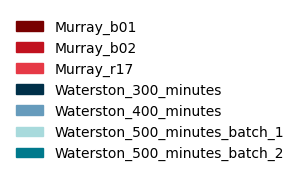

In [67]:
# Get categories and colors
cats = adata.obs["batch"].cat.categories
colors = adata.uns["batch_colors"]

# Create legend handles
handles = [mpatches.Patch(color=c, label=cat) for c, cat in zip(colors, cats)]

# Make a figure with just the legend
fig_legend = plt.figure(figsize=(3, len(handles)*0.3))
ax = fig_legend.add_subplot(111)
ax.axis("off")
ax.legend(handles=handles, loc="center", frameon=False)

fig_legend.savefig(os.path.join(plots_dir, "batch_leged.svg"), dpi=500)


### Load scvi models.

In [46]:
scvi_models = [scvi.model.SCVI.load(model_path, adata=adata.copy()) for model_path in dim2scvipath]
scvi_models_dict= {
    model.module.n_latent: model for model in scvi_models
}

INFO     File                                                                                                      
         /home/icb/lorenzo.consoli/repos/scFM_density_estimation/dumps/cElegans/scvi_runs/2026-01-19_16-37-05_082d2
         81d/model.pt already downloaded                                                                           


/home/icb/lorenzo.consoli/miniconda3/envs/sc_flow_density/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/icb/lorenzo.consoli/miniconda3/envs/sc_flow_de ...
/home/icb/lorenzo.consoli/miniconda3/envs/sc_flow_density/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


INFO     File                                                                                                      
         /home/icb/lorenzo.consoli/repos/scFM_density_estimation/dumps/cElegans/scvi_runs/2026-01-19_16-37-05_53d36
         1df/model.pt already downloaded                                                                           


/home/icb/lorenzo.consoli/miniconda3/envs/sc_flow_density/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/icb/lorenzo.consoli/miniconda3/envs/sc_flow_de ...
/home/icb/lorenzo.consoli/miniconda3/envs/sc_flow_density/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


INFO     File                                                                                                      
         /home/icb/lorenzo.consoli/repos/scFM_density_estimation/dumps/cElegans/scvi_runs/2026-01-19_16-37-05_00f58
         8ff/model.pt already downloaded                                                                           


...

/home/icb/lorenzo.consoli/miniconda3/envs/sc_flow_density/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)
/home/icb/lorenzo.consoli/miniconda3/envs/sc_flow_density/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/icb/lorenzo.consoli/miniconda3/envs/sc_flow_de ...


INFO     File                                                                                                      
         /home/icb/lorenzo.consoli/repos/scFM_density_estimation/dumps/cElegans/scvi_runs/2026-01-19_16-37-05_c929d
         006/model.pt already downloaded                                                                           
INFO     File                                                                                                      
         /home/icb/lorenzo.consoli/repos/scFM_density_estimation/dumps/cElegans/scvi_runs/2026-01-19_16-32-37_9a5aa
         8f8/model.pt already downloaded                                                                           


/home/icb/lorenzo.consoli/miniconda3/envs/sc_flow_density/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)
/home/icb/lorenzo.consoli/miniconda3/envs/sc_flow_density/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/icb/lorenzo.consoli/miniconda3/envs/sc_flow_de ...


INFO     File                                                                                                      
         /home/icb/lorenzo.consoli/repos/scFM_density_estimation/dumps/cElegans/scvi_runs/2026-01-19_16-32-33_5889a
         086/model.pt already downloaded                                                                           


/home/icb/lorenzo.consoli/miniconda3/envs/sc_flow_density/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)
/home/icb/lorenzo.consoli/miniconda3/envs/sc_flow_density/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/icb/lorenzo.consoli/miniconda3/envs/sc_flow_de ...
/home/icb/lorenzo.consoli/miniconda3/envs/sc_flow_density/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_na

### Read results for each dimension and combination.

In [47]:
results_dict = {}
runs = os.listdir(results_dir)
for idx, run_id in enumerate(runs):
    print(f"Loading run {run_id} {idx}/{len(runs)}")
    run_res_dict = {}
    run_dir = os.path.join(results_dir, run_id)
    run_res_dir = os.path.join(run_dir, "results")
    for res in tqdm(os.listdir(run_res_dir)):
        res_paths = os.path.join(run_res_dir, res)
        res_array_dic = np.load(res_paths)
        run_res_dict[res] = res_array_dic
    results_dict[run_id] = run_res_dict

Loading run 2026-01-19_18-01-31_ac2ffdf2 0/12


100%|██████████| 248/248 [00:08<00:00, 28.66it/s]


Loading run 2026-01-19_18-01-31_51e8f654 1/12


100%|██████████| 248/248 [00:07<00:00, 33.72it/s]


Loading run 2026-01-19_18-01-24_1b886429 2/12


...

100%|██████████| 248/248 [00:06<00:00, 37.26it/s]


Loading run 2026-01-19_18-01-16_277f74fb 10/12


100%|██████████| 248/248 [00:05<00:00, 45.53it/s]


Loading run 2026-01-19_18-01-19_a5ef6692 11/12


100%|██████████| 248/248 [00:05<00:00, 42.34it/s]


### Concatenate results across all combinations for each dimension.

In [48]:
concat_res_dict = {}
for idx, (run, run_dict) in enumerate(results_dict.items()):
    print(f"Loading run {run} {idx}/{len(results_dict)}")
    noise_corrected = []
    llr_corrected = []
    noise_uncorrected = []
    llr_uncorrected = []
    for group_id, group_dict in tqdm(run_dict.items()):
        noise_corrected.append(group_dict["noise_corrected"])
        llr_corrected.append(group_dict["llr_corrected"])
        noise_uncorrected.append(group_dict["noise_uncorrected"])
        llr_uncorrected.append(group_dict["llr_uncorrected"])
    print(f"Concatenating results...")
    noise_corrected = np.concatenate(noise_corrected, axis=0)    
    llr_corrected = np.concatenate(llr_corrected, axis=0)    
    noise_uncorrected = np.concatenate(noise_uncorrected, axis=0)    
    llr_uncorrected = np.concatenate(llr_uncorrected, axis=0)  
    print(f"{noise_corrected.shape=}")
    print(f"{llr_corrected.shape=}")
    print(f"{noise_uncorrected.shape=}")
    print(f"{llr_uncorrected.shape=}")
    dim = noise_corrected.shape[-1]
    concat_res_dict[(run, dim)] = {
        "noise_corrected": noise_corrected,
        "llr_corrected": llr_corrected,
        "noise_uncorrected": noise_uncorrected,
        "llr_uncorrected": llr_uncorrected,
    }


Loading run 2026-01-19_18-01-31_ac2ffdf2 0/12


100%|██████████| 248/248 [00:00<00:00, 1013.82it/s]


Concatenating results...
noise_corrected.shape=(89701, 50)
llr_corrected.shape=(89701,)
noise_uncorrected.shape=(89701, 50)
llr_uncorrected.shape=(89701,)
Loading run 2026-01-19_18-01-31_51e8f654 1/12


100%|██████████| 248/248 [00:00<00:00, 1488.16it/s]


Concatenating results...
noise_corrected.shape=(89701, 2)
llr_corrected.shape=(89701,)
noise_uncorrected.shape=(89701, 2)
llr_uncorrected.shape=(89701,)
Loading run 2026-01-19_18-01-24_1b886429 2/12


...

Concatenating results...
noise_corrected.shape=(89701, 100)
llr_corrected.shape=(89701,)
noise_uncorrected.shape=(89701, 100)
llr_uncorrected.shape=(89701,)
Loading run 2026-01-19_18-01-16_277f74fb 10/12


100%|██████████| 248/248 [00:00<00:00, 1848.55it/s]


Concatenating results...
noise_corrected.shape=(89701, 5)
llr_corrected.shape=(89701,)
noise_uncorrected.shape=(89701, 5)
llr_uncorrected.shape=(89701,)
Loading run 2026-01-19_18-01-19_a5ef6692 11/12


100%|██████████| 248/248 [00:00<00:00, 1731.59it/s]

Concatenating results...
noise_corrected.shape=(89701, 10)
llr_corrected.shape=(89701,)
noise_uncorrected.shape=(89701, 10)
llr_uncorrected.shape=(89701,)


## Plot results of log density ratio computation.

### Plot histogram of mean absolute log ratio.

In [49]:
dim2fig_abs = {}

for (run, dim), arrays_dict in tqdm(concat_res_dict.items()):
    xticks = dim2xticks.get(dim, None)
    yticks = dim2yticks.get(dim, None)
    xlim = dim2xlim.get(dim, None)
    ylim = dim2ylim.get(dim, None)

    run_dir = os.path.join(results_dir, run)
    run_plots_dir = os.path.join(run_dir, "plots_agg")
    os.makedirs(run_plots_dir, exist_ok=True)

    llr_corrected = np.abs(arrays_dict["llr_corrected"])
    llr_uncorrected = np.abs(arrays_dict["llr_uncorrected"])
    fig, handles, labels = plot_llr_densities(
        llr_corrected,
        llr_uncorrected,
        f"Dimension {dim}",
        "Mean Absolute Log Ratio",
        xticks=xticks,
        yticks=yticks,
        xlim=xlim,
        ylim=ylim,
    )
    dim2fig_abs[(run, dim)] = fig

    fig_legend = plt.figure(figsize=(2, 2))
    ax = fig_legend.add_subplot(111)  # Add a dummy axes
    ax.axis("off")

    fig_legend.legend(
        handles,
        labels,
        loc="center",
        fontsize=50,
        ncol=30,
        frameon=False
    )
    fig_legend.tight_layout()
    legend_path = os.path.join(run_plots_dir, "legend.svg")
    fig_legend.savefig(legend_path, dpi=300, bbox_inches="tight")
    plt.close(fig_legend)

    image_path = os.path.join(run_plots_dir, "llr_abs.svg")
    fig.savefig(image_path, dpi=500)
    plt.close(fig)


100%|██████████| 12/12 [00:19<00:00,  1.59s/it]


### Boxplot of mean absolute log density ratio.

In [50]:
box_dim2fig_abs = {}

for (run, dim), arrays_dict in tqdm(concat_res_dict.items()):
    xticks = dim2xticks.get(dim, None)
    yticks = dim2yticks.get(dim, None)
    xlim = dim2xlim.get(dim, None)
    ylim = dim2ylim.get(dim, None)

    run_dir = os.path.join(results_dir, run)
    run_plots_dir = os.path.join(run_dir, "plots_agg")
    os.makedirs(run_plots_dir, exist_ok=True)

    llr_corrected = np.abs(arrays_dict["llr_corrected"])
    llr_uncorrected = np.abs(arrays_dict["llr_uncorrected"])
    fig, handles, labels = plot_llr_boxplot(
        llr_corrected,
        llr_uncorrected,
        f"Dimension {dim}",
        "Mean Absolute Log Ratio",
        # xticks=xticks,
        # yticks=yticks,
        # xlim=xlim,
        # ylim=ylim,
        horizontal=True,
        show_outliers=False,
        linewidth=10,
        xticks_size=30,
        yticks_size=30,
        xlabelsize=30,
        ylabelsize=40,
    )
    box_dim2fig_abs[(run, dim)] = fig

    # break
    image_path = os.path.join(run_plots_dir, "no_outliers_horizontal_boxplot_llr_abs.svg")
    fig.savefig(image_path, dpi=500)
    plt.close(fig)


  0%|          | 0/12 [00:00<?, ?it/s]/tmp/ipykernel_2390060/19291470.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
  8%|▊         | 1/12 [00:00<00:05,  1.86it/s]/tmp/ipykernel_2390060/19291470.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
 17%|█▋        | 2/12 [00:01<00:05,  1.71it/s]/tmp/ipykernel_2390060/19291470.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
 25%|██▌       | 3/12 [00:01<00:05,  1.71it/s]/tmp/ipykernel_2390060/19291470.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated a

## Plot states.

### Uncorrected cell states.

In [62]:
compute_stuff = False
s = 15

uncorr_dim2umap_batch = {}
uncorr_dim2umap_cell_type = {}
for d in tqdm(dims):
    batch_dim_file = os.path.join(plots_dir, f"umap_{d}_hvgs_only_batch_size{s}.png")
    cell_type_dim_file = os.path.join(plots_dir, f"umap_{d}_hvgs_only_cell_type_size{s}.png")
    if compute_stuff:
        sc.pp.pca(adata, n_comps=d, key_added=f"X_pca_{d}")
        sc.pp.neighbors(adata, use_rep=f"X_pca_{d}", key_added=f"neighbors_pca_{d}")
        sc.tl.umap(adata, neighbors_key=f"neighbors_pca_{d}", key_added=f"umap_pca_{d}",)
    fig_batch = sc.pl.embedding(adata, f"umap_pca_{d}", color="batch", s=s, frameon=False, legend_loc=None, return_fig=True)
    fig_cell_type = sc.pl.embedding(adata, f"umap_pca_{d}", color="cell_type", s=s, frameon=False, legend_loc=None, return_fig=True)
    fig_batch.savefig(batch_dim_file, dpi=500)
    fig_cell_type.savefig(cell_type_dim_file, dpi=500)
    uncorr_dim2umap_batch[d] = fig_batch
    uncorr_dim2umap_cell_type[d] = fig_cell_type
    plt.close(fig_cell_type)
    plt.close(fig_batch)

100%|██████████| 6/6 [00:11<00:00,  1.97s/it]


### Corrected cell states.

In [61]:
compute_stuff = False
corr_dim2umap_batch = {}
corr_dim2umap_cell_type = {}
s = 15
adata = adata[:, adata.var["highly_variable"]]
for d in tqdm(dims):
    if compute_stuff:
        scvi_model = scvi_models_dict[d]
        adata.obsm[f"X_scvi_{d}"] = scvi_model.get_latent_representation()

        sc.pp.neighbors(adata, use_rep=f"X_scvi_{d}", key_added=f"neighbors_scvi_{d}")
        sc.tl.umap(adata, neighbors_key=f"neighbors_scvi_{d}", key_added=f"umap_scvi_{d}", min_dist=0.3)
    batch_dim_file = os.path.join(plots_dir, f"scvi_umap_{d}_hvgs_only_batch_size{s}.png")
    cell_type_dim_file = os.path.join(plots_dir, f"scvi_umap_{d}_hvgs_only_cell_type_size{s}.png")

    fig_batch = sc.pl.embedding(adata, f"umap_scvi_{d}", color="batch", s=s, frameon=False, legend_loc=None, return_fig=True)
    fig_cell_type = sc.pl.embedding(adata, f"umap_scvi_{d}", color="cell_type", s=s, frameon=False, legend_loc=None, return_fig=True)

    fig_batch.savefig(batch_dim_file, dpi=500)
    fig_cell_type.savefig(cell_type_dim_file, dpi=500)
    corr_dim2umap_batch[d] = fig_batch
    corr_dim2umap_cell_type[d] = fig_cell_type
    plt.close(fig_cell_type)
    plt.close(fig_batch)

100%|██████████| 6/6 [00:11<00:00,  1.99s/it]
